# Day 6 – Multi-Strategy Comparison (EURUSD)

## Objective
Compare multiple trading strategies to determine which performs best under different market conditions.

## Strategies
- SMA crossover (trend)
- RSI (mean-reversion)
- MACD (momentum)

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#Create Output Folders
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [3]:
#Load Dataset
file_path = r"C:\Users\THIS PC\Desktop\quant-finance-portfolio\day-01-market-data-analysis\data\eurusd_daily_raw.csv"
df = pd.read_csv(file_path, index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [5]:
#Build ALL Indicators
# SMA
df["SMA_20"] = df["close"].rolling(20).mean()
df["SMA_50"] = df["close"].rolling(50).mean()

# RSI
delta = df["close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

# MACD
df["EMA_12"] = df["close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["close"].ewm(span=26, adjust=False).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

#Building Strategies

In [7]:
#Strategy 1:SMA
df["SMA_signal"] = np.where(df["SMA_20"] > df["SMA_50"], 1, 0)
df["SMA_position"] = df["SMA_signal"].shift(1)
df["SMA_return"] = df["SMA_position"] * df["simple_return"]
df["SMA_equity"] = (1 + df["SMA_return"]).cumprod()

In [8]:
#Strategy 2: RSI :Buy when RSI < 30 Exit when RSI > 50
df["RSI_signal"] = np.where(df["RSI_14"] < 30, 1, 0)
df["RSI_position"] = df["RSI_signal"].shift(1)
df["RSI_return"] = df["RSI_position"] * df["simple_return"]
df["RSI_equity"] = (1 + df["RSI_return"]).cumprod()

In [9]:
#Strategy 3:MACD
df["MACD_signal_bin"] = np.where(df["MACD"] > df["MACD_signal"], 1, 0)
df["MACD_position"] = df["MACD_signal_bin"].shift(1)
df["MACD_return"] = df["MACD_position"] * df["simple_return"]
df["MACD_equity"] = (1 + df["MACD_return"]).cumprod()

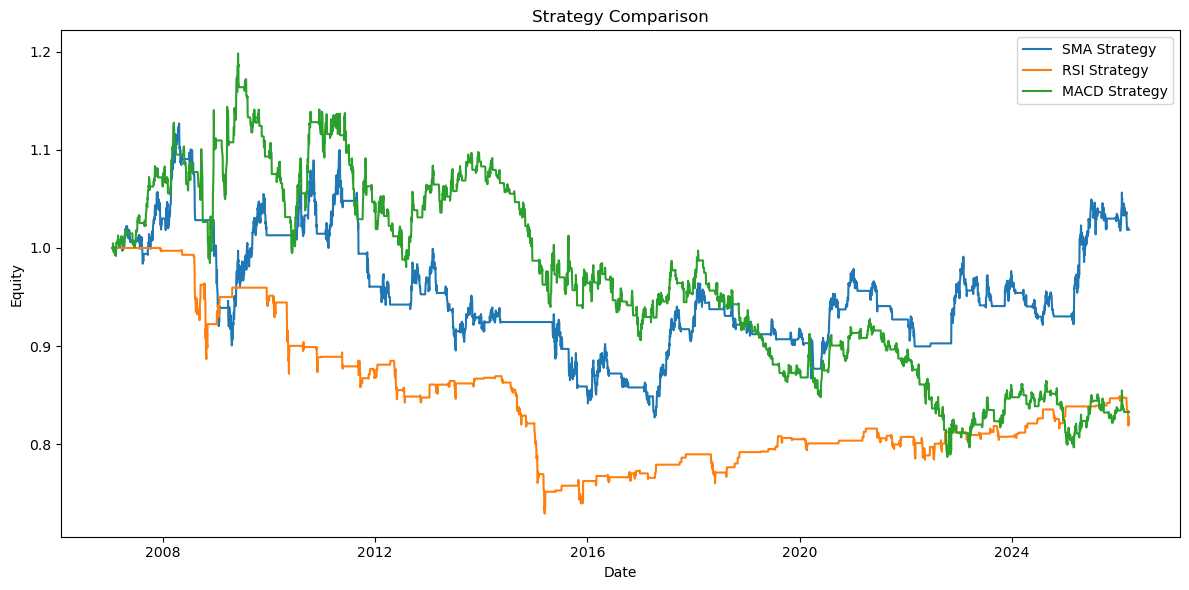

In [10]:
#Compare Equity Curve
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["SMA_equity"], label="SMA Strategy")
plt.plot(df.index, df["RSI_equity"], label="RSI Strategy")
plt.plot(df.index, df["MACD_equity"], label="MACD Strategy")

plt.title("Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/charts/day06_strategy_comparison.png")
plt.show()

In [11]:
#Performance Metrics Table
def get_metrics(ret, equity):
    total_return = equity.iloc[-1] - 1
    annual_return = ret.mean() * 252
    annual_vol = ret.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol
    return total_return, annual_return, annual_vol, sharpe

metrics = pd.DataFrame({
    "Strategy": ["SMA", "RSI", "MACD"],
    "Total Return": [
        get_metrics(df["SMA_return"], df["SMA_equity"])[0],
        get_metrics(df["RSI_return"], df["RSI_equity"])[0],
        get_metrics(df["MACD_return"], df["MACD_equity"])[0]
    ],
    "Sharpe": [
        get_metrics(df["SMA_return"], df["SMA_equity"])[3],
        get_metrics(df["RSI_return"], df["RSI_equity"])[3],
        get_metrics(df["MACD_return"], df["MACD_equity"])[3]
    ]
})

metrics

,Strategy,Total Return,Sharpe
0,SMA,0.018680,0.045181
1,RSI,-0.178705,-0.267822
2,MACD,-0.167234,-0.115117


In [12]:
#Save Result
metrics.to_csv("outputs/tables/day06_metrics.csv", index=False)
df.to_csv("outputs/tables/day06_data.csv")

## Analyst Interpretation

This analysis compares three different trading approaches applied to the same EURUSD data, each based on a different idea about how markets behave.

The first strategy (SMA) follows trends, meaning it attempts to stay in the market when prices are moving in a clear direction. The second strategy (RSI) focuses on reversals, entering trades when the market appears overbought or oversold. The third strategy (MACD) captures momentum, aiming to detect when price movements are accelerating or slowing down.

Looking at the equity curves, we can see how each strategy grows over time. Some strategies show smoother and more consistent growth, while others experience more fluctuations. This reflects how each method responds differently to changing market conditions.

The performance metrics provide a deeper understanding of these results:

- **Total Return** shows how much each strategy gained or lost over the entire period. A higher value means stronger overall performance, but it does not tell us how stable that performance was.

- **Volatility** measures how much the returns fluctuate. Higher volatility means the strategy experiences larger swings, which can make it more difficult to manage in real trading.

- **Sharpe Ratio** is one of the most important metrics because it combines return and risk. It shows how much return is achieved for each unit of risk taken. A higher Sharpe ratio indicates a more efficient and balanced strategy.

- **Drawdown** reflects the largest drop from a peak to a low point. This is especially important from a practical perspective, as it shows the potential losses a trader would have to endure during difficult periods.

From the results, it becomes clear that no single strategy performs best in all situations. Some strategies perform well during strong trends, while others are more effective when the market moves sideways or reverses direction.

This highlights an important principle in trading:

👉 Different strategies work better under different market conditions.

It also reinforces that evaluating a strategy based only on total return is not enough. A strategy with high returns but large drawdowns or high volatility may be difficult to sustain in real-world trading.

Overall, this comparison demonstrates the importance of balancing return, risk, and consistency. It also shows why many traders combine multiple strategies rather than relying on a single approach.

## Key Takeaways

- There is no single “best” strategy for all market conditions  
- Higher returns do not always mean better performance  
- Risk and consistency are just as important as profitability  
- Different strategies respond differently to market behavior  
- Combining strategies may lead to more stable results  